In [104]:
import matplotlib.pyplot as plt
import numpy as np
from ngsolve import GridFunction
import ipywidgets as widgets
from ipywidgets import interact
from pymor.core.pickle import load

from fom import create_fom

fom = create_fom(nt=300, h=50, time=9)

# access parameter study

with open('brusselator_parameters.pkl', 'rb') as f:
    parameterstudy = load(f)

# access std snapshots

with open('std_Brusselator_snapshots.pkl', 'rb') as f:
    old_snapshots1 = load(f)
std_Brusselator_snapshots = fom.solution_space.from_numpy(old_snapshots1.to_numpy())

len(std_Brusselator_snapshots)

# access the enriched snapshots

with open('enriched_Brusselator_snapshots_DaDt.pkl', 'rb') as f:
    snapshots_enriched_DaDt = load(f)

with open('enriched_Brusselator_snapshots_DtDa.pkl', 'rb') as f:
    snapshots_enriched_DtDa = load(f)

print(f"Loaded std snapshots: {len(std_Brusselator_snapshots)}")
print(f"Loaded DaDt snapshots: {len(snapshots_enriched_DaDt)}")
print(f"Loaded DtDa snapshots: {len(snapshots_enriched_DtDa)}")

Loaded std snapshots: 260
Loaded DaDt snapshots: 260
Loaded DtDa snapshots: 260


In [105]:
# std POD

r_std = 60

from pymor.algorithms.pod import pod
std_pod_basis, std_pod_singular_values = pod(std_Brusselator_snapshots,
                                     product=fom.products['h1_0_semi'],
                                     method= 'qr_svd',
                                     modes=r_std,
                                     rtol=1e-12,   
                                     atol=0.0 
                                    )
len(std_pod_basis)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

c:\Users\laraf\anaconda3\Lib\site-packages\pymor\bindings\scipy.py:31: UserWarning: Your SciPy installation seems to be using MKL as LAPACK library.
To avoid stability issues on Windows, we use gesdd instead of gesvd
for SVD computation. This may lead to reduced numerical accuracy.
See https://github.com/pymor/pymor/issues/2391 for further discussion.
To silence this warning, set the pymor.bindings.scipy.svd_lapack_driver.driver
default to either "gesvd" or "gesdd".
  warn('Your SciPy installation seems to be using MKL as LAPACK library.\n'


60

In [106]:
# enriched POD with DtDa

r_std = 60

snapshots_enriched_DtDa = fom.solution_space.from_numpy(snapshots_enriched_DtDa.to_numpy())

from pymor.algorithms.pod import pod
enriched_DtDa_pod_basis, enriched_DtDa_pod_singular_values = pod(snapshots_enriched_DtDa,
                                     product=fom.products['h1_0_semi'],
                                     modes=r_std, 
                                     method= 'qr_svd', 
                                     rtol=1e-11,   
                                     atol=1e-10,
                                     #orth_tol= 1e-8
                                    )
len(enriched_DtDa_pod_basis)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

60

In [107]:
# enriched POD with DaDt

r_std = 60

snapshots_enriched_DaDt = fom.solution_space.from_numpy(snapshots_enriched_DaDt.to_numpy())

from pymor.algorithms.pod import pod
enriched_DaDt_pod_basis, enriched_DaDt_pod_singular_values = pod(snapshots_enriched_DaDt,
                                     product=fom.products['h1_0_semi'],
                                     modes=r_std, 
                                     method= 'qr_svd', 
                                     rtol=1e-14,   
                                     atol=1e-14,
                                     #orth_tol= 1e-8
                                    )
len(enriched_DaDt_pod_basis)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

60

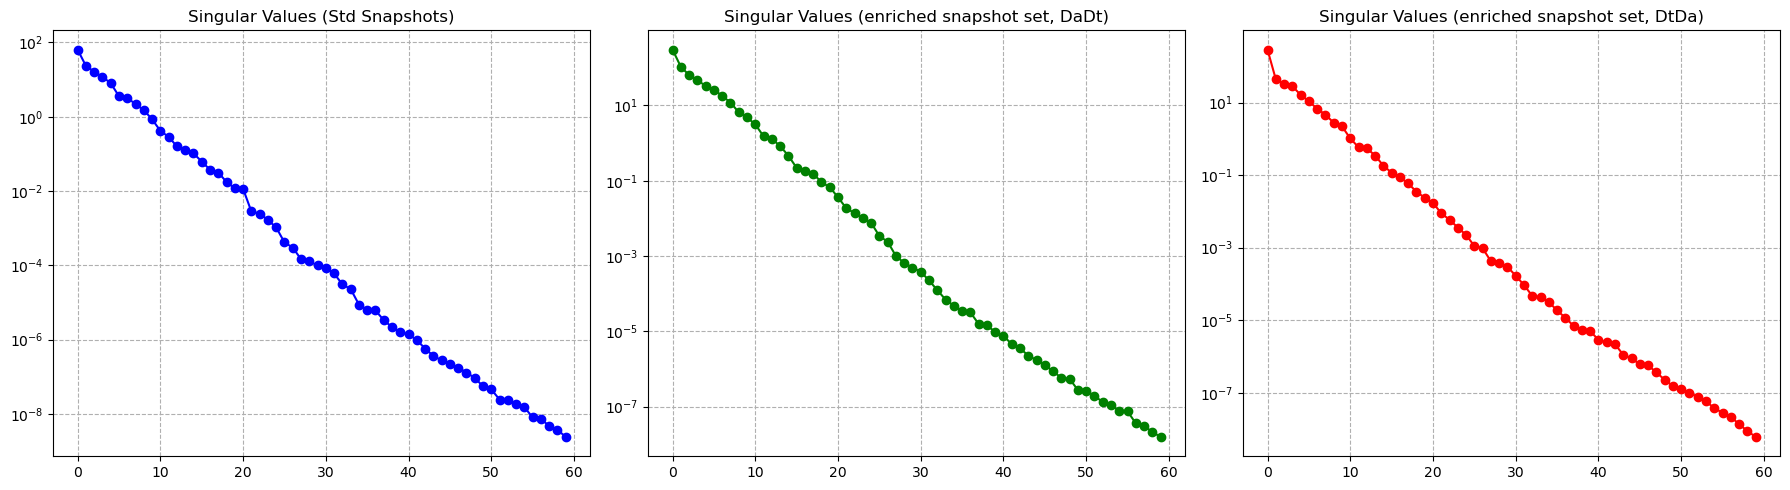

In [108]:
# plot the singular values

import matplotlib.pyplot as plt

fig, axs = plt.subplots(1,3, figsize=(18, 5))

axs[0].semilogy(std_pod_singular_values, marker='o', color='blue')
axs[0].set_title("Singular Values (Std Snapshots)")
axs[0].grid(True, which="both", ls="--")

axs[1].semilogy(enriched_DaDt_pod_singular_values, marker='o', color='green')
axs[1].set_title("Singular Values (enriched snapshot set, DaDt)")
axs[1].grid(True, which="both", ls="--")

axs[2].semilogy(enriched_DtDa_pod_singular_values, marker='o', color='red')
axs[2].set_title("Singular Values (enriched snapshot set, DtDa)")
axs[2].grid(True, which="both", ls="--")

plt.tight_layout()
plt.show()

In [109]:
# construct std POD-ROM 

from pymor.reductors.parabolic import ParabolicRBReductor

r=20

beta= 3.75  # chose sample parameter here

data = parameterstudy[beta]
T_per = data['period']
u0_array = data['initial_data']

fom = create_fom(nt=300, h=50, time=T_per, initial_array=u0_array)

RB_adapted = fom.solution_space.from_numpy(std_pod_basis[:r].to_numpy())

reductor_std = ParabolicRBReductor(
       fom=fom,
       RB=RB_adapted,
       product=fom.h1_0_semi_product,
       coercivity_estimator=None,
       check_orthonormality=False,
       check_tol=1e-10
   )

rom_std_r = reductor_std.reduce()   # create r-dim rom
u_rom_std = rom_std_r.solve(beta) # solve rom for this mu in low dim
std_rom_rec = reductor_std.reconstruct(u_rom_std) # back to high dim

len(std_rom_rec)


Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

301

In [110]:
# construct enriched POD-ROM (DtDa)

RB_adapted = fom.solution_space.from_numpy(enriched_DtDa_pod_basis[:r].to_numpy())

reductor_DtDa = ParabolicRBReductor(
       fom=fom,
       RB=RB_adapted,
       product=fom.h1_0_semi_product,
       coercivity_estimator=None,
       check_orthonormality=False,
       check_tol=1e-10
   )

rom_DtDa_r = reductor_DtDa.reduce()         # create r-dim rom
u_rom_DtDa = rom_DtDa_r.solve(beta)         # solve rom for this mu in low dim
DtDa_rom_rec = reductor_DtDa.reconstruct(u_rom_DtDa) # back to high dim

len(DtDa_rom_rec)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

301

In [111]:
# construct enriched POD-ROM (DaDt)

RB_adapted = fom.solution_space.from_numpy(enriched_DaDt_pod_basis[:r].to_numpy())

reductor_DaDt = ParabolicRBReductor(
       fom=fom,
       RB=RB_adapted,
       product=fom.h1_0_semi_product,
       coercivity_estimator=None,
       check_orthonormality=False,
       check_tol=1e-10
   )

rom_DaDt_r = reductor_DaDt.reduce()         # create r-dim rom
u_rom_DaDt = rom_DaDt_r.solve(beta)         # solve rom for this mu in low dim
DaDt_rom_rec = reductor_DaDt.reconstruct(u_rom_DaDt) # back to high dim

len(DaDt_rom_rec)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

301

In [112]:
# compute fom solution for beta as a reference for the error analysis
    
U_trajectory = fom.solve(beta)

len(U_trajectory)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

301

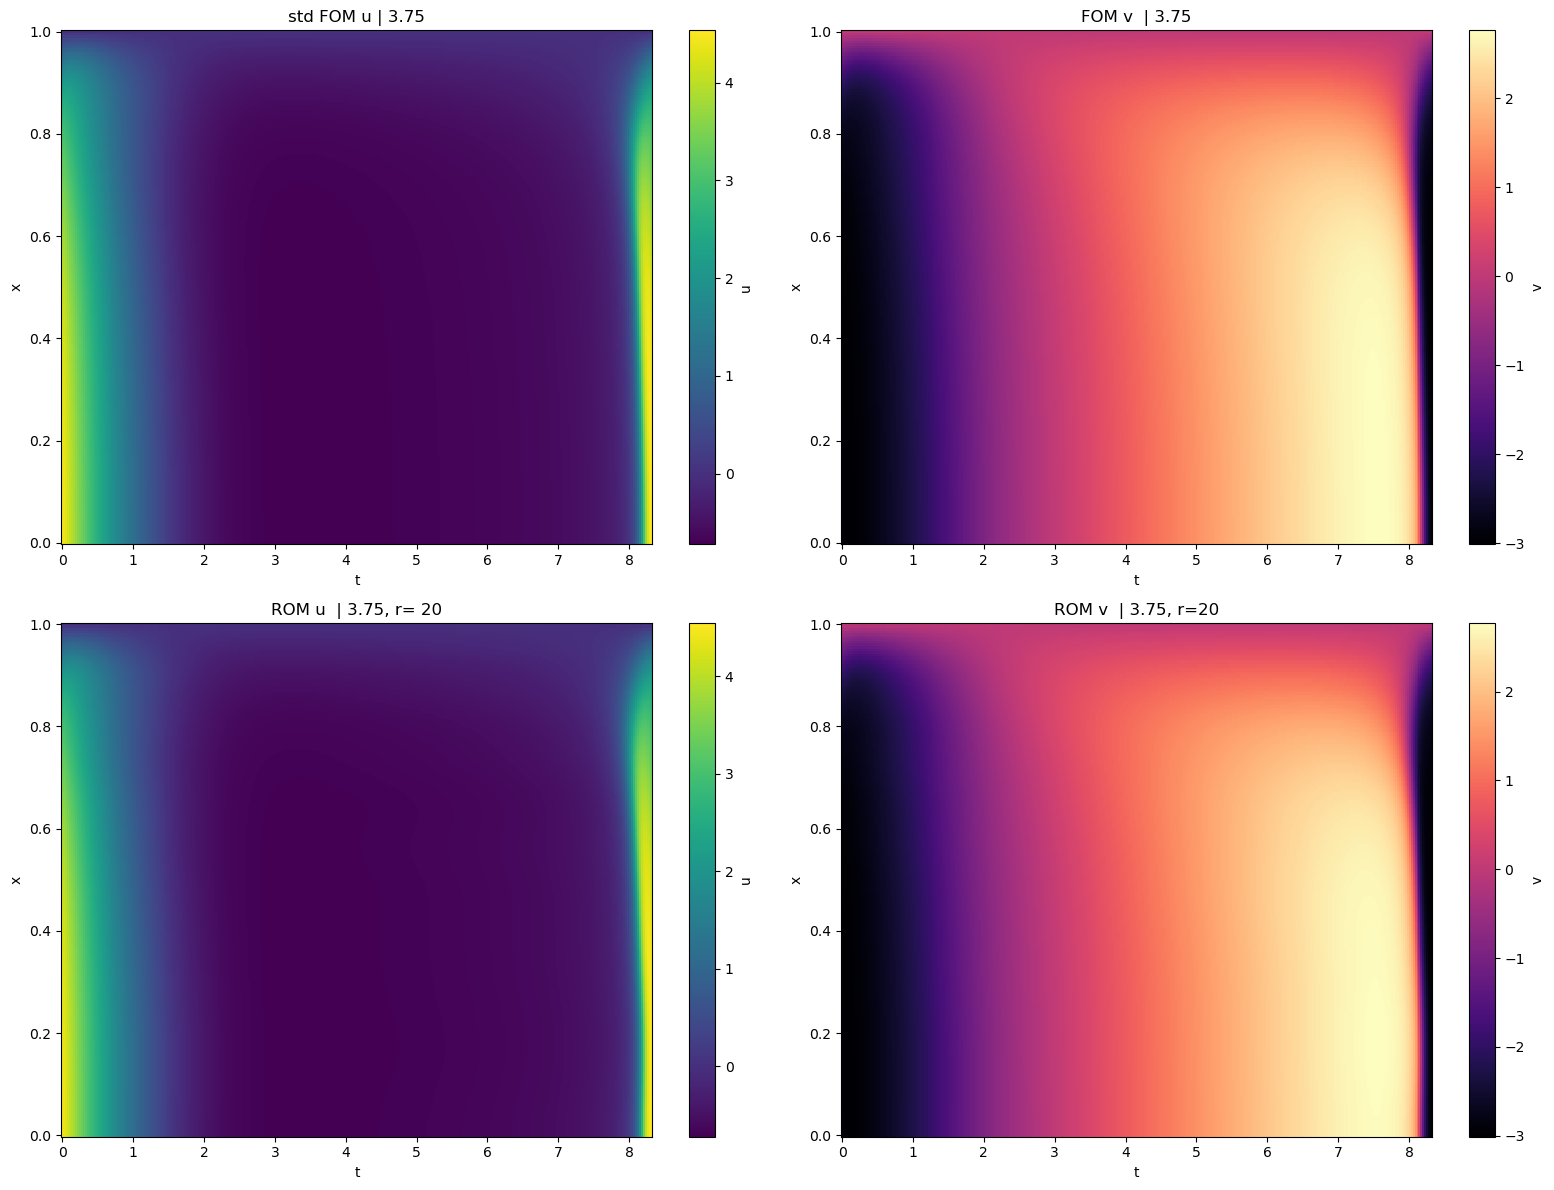

In [113]:
# plot the std POD-ROM, compared to the FOM solution

V_h = fom.operator.V_h
mesh = V_h.mesh
x_werte = np.linspace(0, 1, 200)
gfu_plot = GridFunction(V_h)

num_x_points = 200
num_t_points = len(std_rom_rec) 

x_werte = np.linspace(0, 1, num_x_points)
t_werte = np.linspace(0, fom.T, num_t_points)

u_matrix_rom = np.zeros((num_x_points, num_t_points))
v_matrix_rom = np.zeros((num_x_points, num_t_points))

u_matrix_fom = np.zeros((num_x_points, num_t_points))
v_matrix_fom = np.zeros((num_x_points, num_t_points))

gfu_plot = GridFunction(V_h)

for t_idx in range(num_t_points):
   
    vec_pymor_rom = std_rom_rec[t_idx].vectors[0].real_part
    gfu_plot.vec.data = vec_pymor_rom.impl.vec 
    
    u_matrix_rom[:, t_idx] = [gfu_plot.components[0](mesh(x)) for x in x_werte]
    v_matrix_rom[:, t_idx] = [gfu_plot.components[1](mesh(x)) for x in x_werte]

    vec_pymor_fom = U_trajectory[t_idx].vectors[0].real_part
    gfu_plot.vec.data = vec_pymor_fom.impl.vec 
    
    u_matrix_fom[:, t_idx] = [gfu_plot.components[0](mesh(x)) for x in x_werte]
    v_matrix_fom[:, t_idx] = [gfu_plot.components[1](mesh(x)) for x in x_werte]

T, X = np.meshgrid(t_werte, x_werte)

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
c1 = axs[0, 0].pcolormesh(T, X, u_matrix_fom, cmap='viridis', shading='auto', vmin=None, vmax=None)
axs[0, 0].set_title(f"std FOM u | {beta}")
axs[0, 0].set_xlabel("t")
axs[0, 0].set_ylabel("x")
fig.colorbar(c1, ax=axs[0, 0], label="u")

c2 = axs[0, 1].pcolormesh(T, X, v_matrix_fom, cmap='magma', shading='auto', vmin=None, vmax=None)
axs[0, 1].set_title(f"FOM v  | {beta}")
axs[0, 1].set_xlabel("t")
axs[0, 1].set_ylabel("x")
fig.colorbar(c2, ax=axs[0, 1], label="v")

c3 = axs[1, 0].pcolormesh(T, X, u_matrix_rom, cmap='viridis', shading='auto', vmin=None, vmax=None)
axs[1, 0].set_title(f"ROM u  | {beta}, r= {r}")
axs[1, 0].set_xlabel("t")
axs[1, 0].set_ylabel("x")
fig.colorbar(c3, ax=axs[1, 0], label="u")

c4 = axs[1, 1].pcolormesh(T, X, v_matrix_rom, cmap='magma', shading='auto', vmin=None, vmax=None)
axs[1, 1].set_title(f"ROM v  | {beta}, r={r}")
axs[1, 1].set_xlabel("t")
axs[1, 1].set_ylabel("x")
fig.colorbar(c4, ax=axs[1, 1], label="v")
plt.tight_layout()
plt.show()

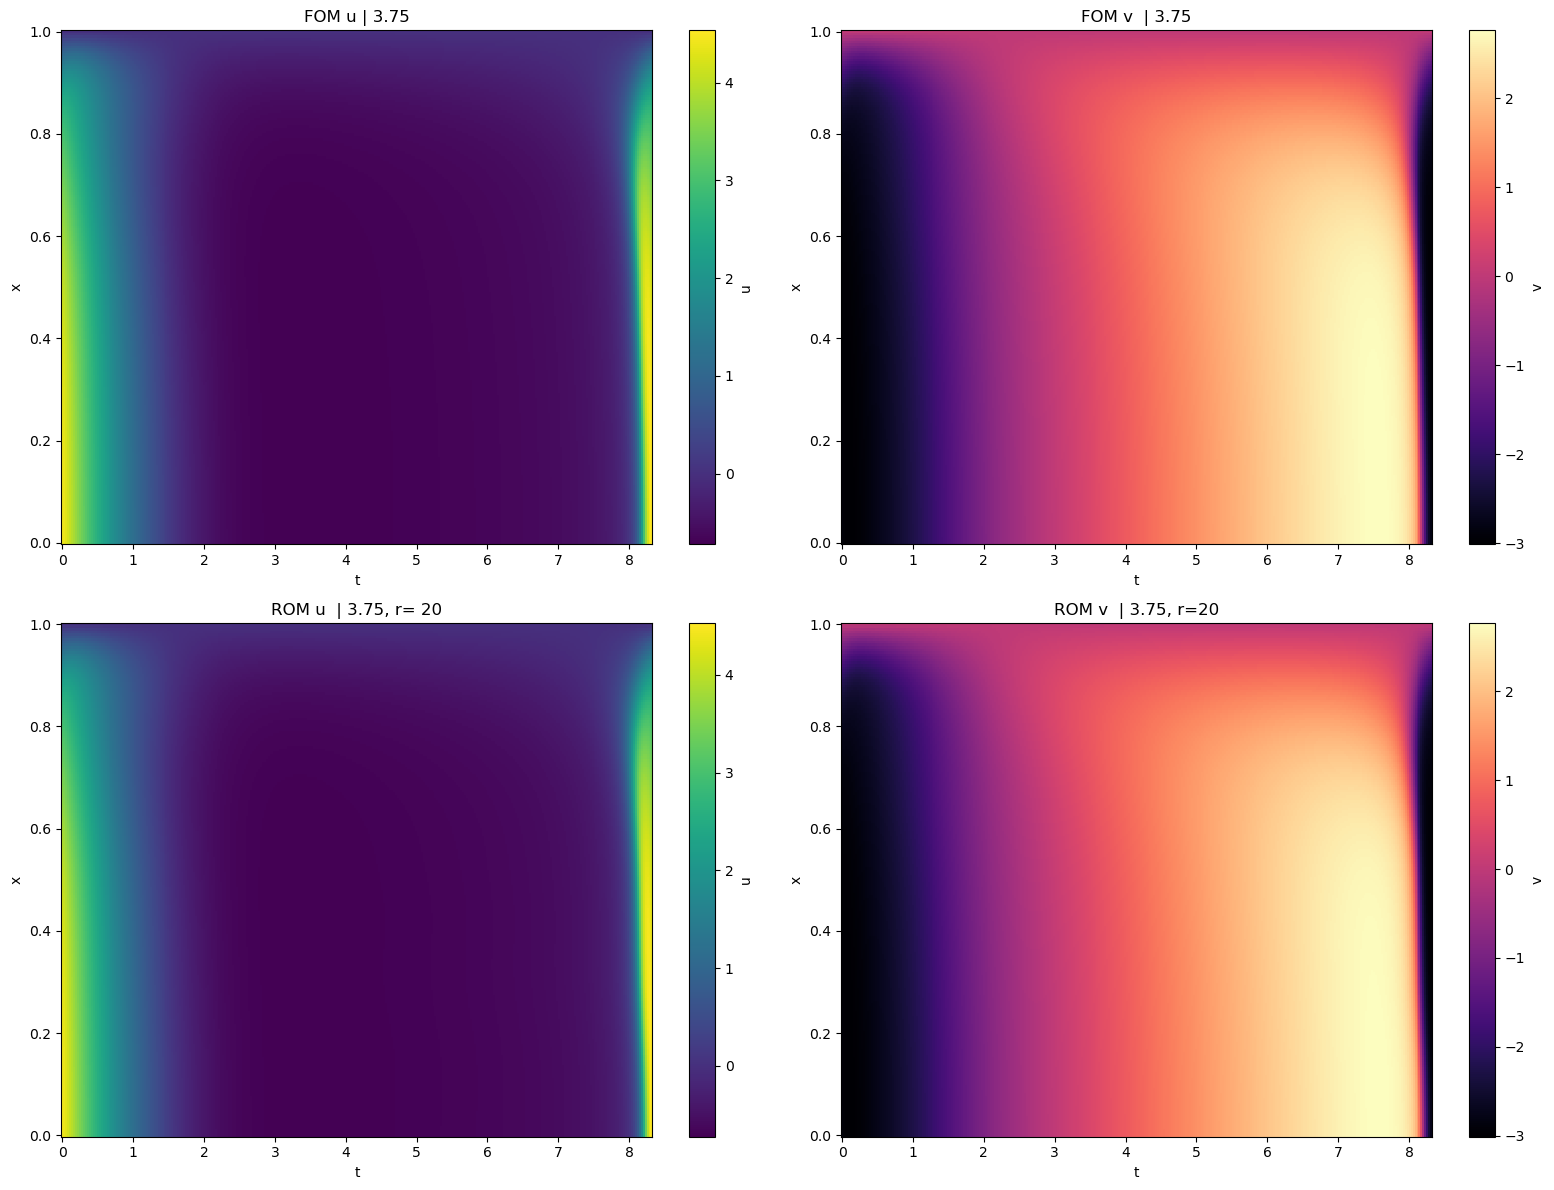

In [114]:
# plot enriched POD-ROM, compared to FOM solution

num_x_points = 200
num_t_points = len(std_rom_rec) 

x_werte = np.linspace(0, 1, num_x_points)
t_werte = np.linspace(0, fom.T, num_t_points)

u_matrix_rom = np.zeros((num_x_points, num_t_points))
v_matrix_rom = np.zeros((num_x_points, num_t_points))

u_matrix_fom = np.zeros((num_x_points, num_t_points))
v_matrix_fom = np.zeros((num_x_points, num_t_points))

gfu_plot = GridFunction(V_h)

for t_idx in range(num_t_points):
   
    vec_pymor_rom = DaDt_rom_rec[t_idx].vectors[0].real_part
    gfu_plot.vec.data = vec_pymor_rom.impl.vec 
    
    u_matrix_rom[:, t_idx] = [gfu_plot.components[0](mesh(x)) for x in x_werte]
    v_matrix_rom[:, t_idx] = [gfu_plot.components[1](mesh(x)) for x in x_werte]

    vec_pymor_fom = U_trajectory[t_idx].vectors[0].real_part
    gfu_plot.vec.data = vec_pymor_fom.impl.vec 
    
    u_matrix_fom[:, t_idx] = [gfu_plot.components[0](mesh(x)) for x in x_werte]
    v_matrix_fom[:, t_idx] = [gfu_plot.components[1](mesh(x)) for x in x_werte]

T, X = np.meshgrid(t_werte, x_werte)

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

c1 = axs[0, 0].pcolormesh(T, X, u_matrix_fom, cmap='viridis', shading='auto', vmin=None, vmax=None)
axs[0, 0].set_title(f"FOM u | {beta}")
axs[0, 0].set_xlabel("t")
axs[0, 0].set_ylabel("x")
fig.colorbar(c1, ax=axs[0, 0], label="u")

c2 = axs[0, 1].pcolormesh(T, X, v_matrix_fom, cmap='magma', shading='auto', vmin=None, vmax=None)
axs[0, 1].set_title(f"FOM v  | {beta}")
axs[0, 1].set_xlabel("t")
axs[0, 1].set_ylabel("x")
fig.colorbar(c2, ax=axs[0, 1], label="v")

c3 = axs[1, 0].pcolormesh(T, X, u_matrix_rom, cmap='viridis', shading='auto', vmin=None, vmax=None)
axs[1, 0].set_title(f"ROM u  | {beta}, r= {r}")
axs[1, 0].set_xlabel("t")
axs[1, 0].set_ylabel("x")
fig.colorbar(c3, ax=axs[1, 0], label="u")

c4 = axs[1, 1].pcolormesh(T, X, v_matrix_rom, cmap='magma', shading='auto', vmin=None, vmax=None)
axs[1, 1].set_title(f"ROM v  | {beta}, r={r}")
axs[1, 1].set_xlabel("t")
axs[1, 1].set_ylabel("x")
fig.colorbar(c4, ax=axs[1, 1], label="v")
#plt.savefig('test rom nt=100.pdf', bbox_inches='tight')  # save figure
plt.tight_layout()
plt.show()

In [115]:
# #  now we consider different values for r and max over t, still one parameter, std ROM

# import gc 

# max_r = 22
# r_values = range(1, max_r + 1, 5) 
# errors_std = []
# errors_proj_std = []

# for r in r_values:

#         print(f"start{r}")
 
#         rom_r_std = reductor_std.reduce(dims={'RB': r})  # construct ROM with r modes
#         u_rom_std = rom_r_std.solve(beta) # solve for testmu
#         u_rec_std = reductor_std.reconstruct(u_rom_std) # reconstruct to high dim
    
#         err = np.max((U_trajectory - u_rec_std).norm(fom.h1_0_semi_product))   # consider error max{t}\norm{(u_h - u_r^std)}
#         errors_std.append(err)

#         # for std
#         RB_adapted = fom.solution_space.from_numpy(std_pod_basis[:r].to_numpy())

#         coeffs_std = fom.products['h1_0_semi'].apply2(RB_adapted, U_trajectory) 
#         u_projected_std = RB_adapted.lincomb(coeffs_std)              
    
#         error_proj_std_max = np.max((U_trajectory - u_projected_std).norm(fom.products['h1_0_semi'])) # (u_h - Pr(u_h)) max over t
        
#         errors_proj_std.append(error_proj_std_max)
    
#         filename_err_std = f"errors_std_mu_{beta}.npy"
#         filename_proj_std = f"proj_std_mu_{beta}.npy"

#         np.save(filename_err_std, np.array(errors_std))
#         np.save(filename_proj_std, np.array(errors_proj_std))
    
#         del u_rec_std, u_rom_std
#         del u_projected_std
#         gc.collect()

In [116]:
# # same loop for the enriched POD-ROM (DaDt)

# errors_U = []
# errors_proj_U = []

# for r in r_values:

#         print(f"start{r}")

#         rom_r_U = reductor_DaDt.reduce(dims={'RB': r}) # construct ROM with r modes
#         u_rom_U = rom_r_U.solve(beta) # solve for testmu
#         u_rec_U = reductor_DaDt.reconstruct(u_rom_U) # reconstruct to high dim
    
       
#         err = np.max((U_trajectory - u_rec_U).norm(fom.h1_0_semi_product))   # consider error max{t}\norm{(u_h - u_r^std)}
#         errors_U.append(err)

#         RB_adapted = fom.solution_space.from_numpy(enriched_DaDt_pod_basis[:r].to_numpy())
#         coeffs_U = fom.products['h1_0_semi'].apply2(RB_adapted, U_trajectory) 
#         u_projected_U = RB_adapted.lincomb(coeffs_U)              
    
#         error_proj_U_max = np.max((U_trajectory - u_projected_U).norm(fom.products['h1_0_semi'])) # (u_h - Pr(u_h)) max over t
        
#         errors_proj_U.append(error_proj_U_max)

#         filename_err = f"errors_U_mu_{beta}.npy"
#         filename_proj = f"proj_U_mu_{beta}.npy"

#         np.save(filename_err, np.array(errors_U))
#         np.save(filename_proj, np.array(errors_proj_U))
    
#         del u_rec_U 
#         del u_rom_U
#         del u_projected_U
#         gc.collect()
    
    

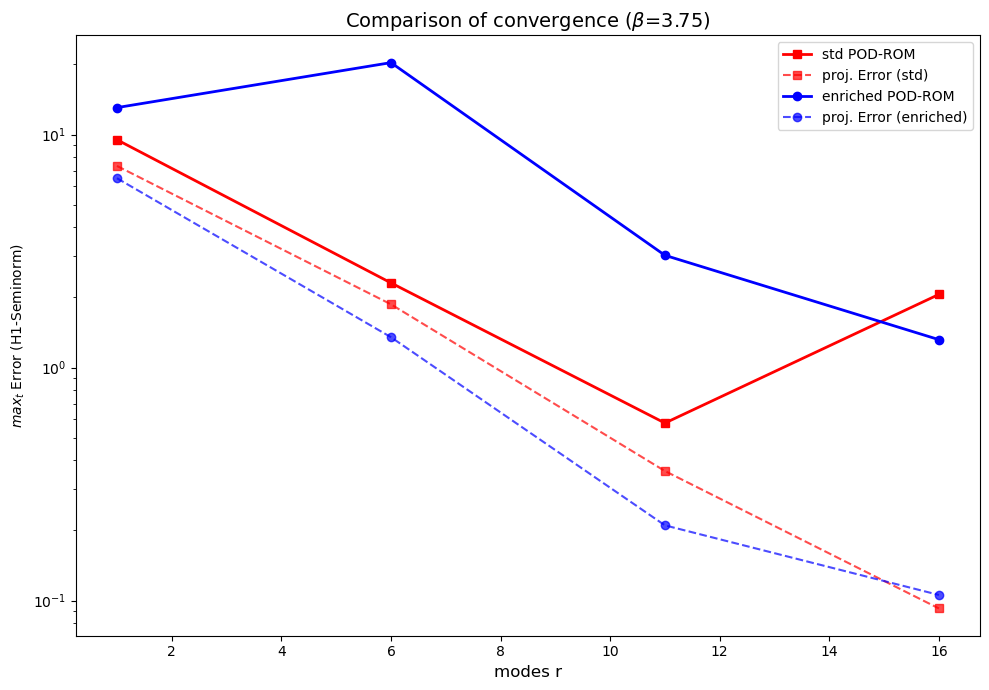

In [117]:
# plot both together

import matplotlib.pyplot as plt

errors_std = np.load(f"errors_std_mu_{beta}.npy")
errors_proj_std = np.load(f"proj_std_mu_{beta}.npy")

errors_U = np.load(f"errors_U_mu_{beta}.npy")
errors_proj_U = np.load(f"proj_U_mu_{beta}.npy")
max_r = 22
r_values = range(1, max_r + 1, 5) 

r_values = r_values[:-1]
errors_std = errors_std[:-1]
errors_proj_std = errors_proj_std[:-1]
errors_U = errors_U[:-1]
errors_proj_U = errors_proj_U[:-1]

plt.figure(figsize=(10, 7))
plt.semilogy(r_values, errors_std, 'r-s', linewidth=2, label='std POD-ROM')
plt.semilogy(r_values, errors_proj_std, 'r--s', alpha=0.7, label='proj. Error (std)')
plt.semilogy(r_values, errors_U, 'b-o', linewidth=2, label='enriched POD-ROM')
plt.semilogy(r_values, errors_proj_U, 'b--o', alpha=0.7, label='proj. Error (enriched)')
plt.xlabel('modes r', fontsize=12)
plt.ylabel(r"$max_{t}$ Error (H1-Seminorm)")
plt.title(fr"Comparison of convergence ($\beta$={beta})", fontsize=14)
plt.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.show()

In [118]:
r=15

#compute std ROM 
rom_std_r = reductor_std.reduce(dims={'RB': r})   # create r-dim rom
u_rom_std = rom_std_r.solve(beta) # solve rom for this mu in low dim
u_rec_std = reductor_std.reconstruct(u_rom_std) # back to high dim

# compute enriched ROM solution
rom_U_r = reductor_DaDt.reduce(dims={'RB': r})
u_rom_U = rom_U_r.solve(beta) # solve rom for this mu in low dim
u_rec_U = reductor_DaDt.reconstruct(u_rom_U) # back to high dim

error_rom_U = (U_trajectory - u_rec_U).norm(fom.products['h1_0_semi'])  # (Pr(u_h) - u_r)
error_rom_std = (U_trajectory - u_rec_std).norm(fom.products['h1_0_semi'])  # (Pr(u_h) - u_r)

# for the error anylysis: (u_h - u_r) = (u_h - Pr(u_h)) + (Pr(u_h) - u_r))

# enriched POD-ROM
RB_adapted = fom.solution_space.from_numpy(enriched_DaDt_pod_basis[:r].to_numpy())
coeffs_U = fom.products['h1_0_semi'].apply2(RB_adapted, U_trajectory) 
u_projected_U = RB_adapted.lincomb(coeffs_U)                       # proj onto U ROM
error_proj_U = (U_trajectory - u_projected_U).norm(fom.products['h1_0_semi']) # (u_h - Pr(u_h))

# std POD-ROM
RB_adapted = fom.solution_space.from_numpy(std_pod_basis[:r].to_numpy())
coeffs_std = fom.products['h1_0_semi'].apply2(RB_adapted, U_trajectory) 
u_projected_std = RB_adapted.lincomb(coeffs_std)              # proj onto std ROM
error_proj_std = (U_trajectory - u_projected_std).norm(fom.products['h1_0_semi']) # (u_h - Pr(u_h)) max over time

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

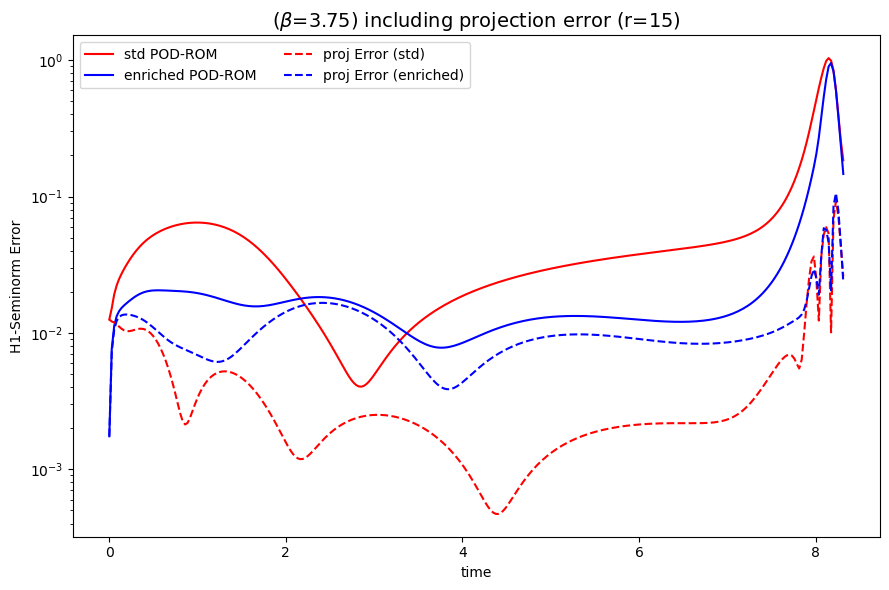

In [119]:

times = np.linspace(0, T_per, 300 + 1)

plt.figure(figsize=(9, 6))

plt.semilogy(times, error_rom_std, color='red', label=f'std POD-ROM')
plt.semilogy(times, error_rom_U, color='blue', label=f'enriched POD-ROM')
plt.semilogy(times, error_proj_std, color='red', linestyle='--', label=f'proj Error (std)')
plt.semilogy(times, error_proj_U, color='blue', linestyle='--', label=f'proj Error (enriched)')
plt.title(fr'($\beta$={beta}) including projection error (r={r})', fontsize=14)
plt.xlabel('time')
plt.ylabel('H1-Seminorm Error')
plt.legend(loc='upper left', ncol=2)

#plt.savefig('Brusselator_3.25_r15.pdf', bbox_inches='tight')

plt.tight_layout()
plt.show()